<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp2_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 (TP2) - Ciência de Dados
## Dataset: MNIST (Visualização de Imagens e Redução de Dimensionalidade)

Este notebook apresenta a resolução da segunda etapa (TP2) para o dataset MNIST. O foco desta etapa é a **Análise Exploratória de Dados (EDA)** em dados de alta dimensionalidade (pixels de imagens), normalização de intensidade de cinza e a aplicação de técnicas de **Análise de Componentes Principais (PCA)** para redução de dimensionalidade e análise espacial.

---

## 1. Revisão da Formalização do Problema e Objetivos

### 1.1 Resumo do Problema
O objetivo é classificar imagens digitalizadas de dígitos escritos à mão de 0 a 9. O problema é de **classificação multiclasse supervisionada** com 10 classes distintas. Cada observação de imagem consiste originalmente de $28 \times 28 = 784$ features numéricas.

### 1.2 Objetivos Pretendidos
*   Visualizar as imagens brutas em formato de matriz bidimensional.
*   Analisar a distribuição de classes na amostra selecionada para certificar o balanceamento dos dados.
*   Computar as imagens "médias" por dígito para compreender os padrões visuais estatísticos de cada algarismo.
*   Aplicar **PCA** para reduzir as 784 dimensões e analisar o percentual de variância explicada acumulada.
*   Definir os algoritmos manuais de classificação a serem testados no TP3.

---

## 2. Análise Exploratória dos Dados (EDA) e Transformações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)

print("Carregando uma amostra estável do dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

# Amostra estratificada de 5.000 instâncias
X_sub, _, y_sub, _ = train_test_split(
    X, y,
    train_size=5000,
    random_state=42,
    stratify=y
)

print(f"Amostra reduzida: {X_sub.shape[0]} imagens com {X_sub.shape[1]} pixels cada.")

Carregando uma amostra estável do dataset MNIST...
Amostra reduzida: 5000 imagens com 784 pixels cada.


### 2.1 A base de dados é adequada?
Sim, a base MNIST é adequada porque as imagens estão centralizadas e pré-processadas no mesmo enquadramento ($28 \times 28$). Além disso, é o benchmark histórico ideal para estudar reconhecimento de padrões estruturais.

### 2.2 Existem dados faltantes?
Como o MNIST é uma base padrão de visão computacional muito curada, não há presença de pixels ausentes (nulos). Todos os valores estão no intervalo inteiro $[0, 255]$.

In [ ]:
# Confirmação de ausência de nulos na amostra
print("Quantidade de valores nulos na matriz de imagens:", np.isnan(X_sub).sum())

Quantidade de valores nulos na matriz de imagens: 0


### 2.3 Visualização das Imagens e Estatísticas de Classes

Vamos gerar visualizações das imagens brutas e analisar o balanceamento das classes.

/tmp/ipykernel_6574/1274190918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette='viridis')


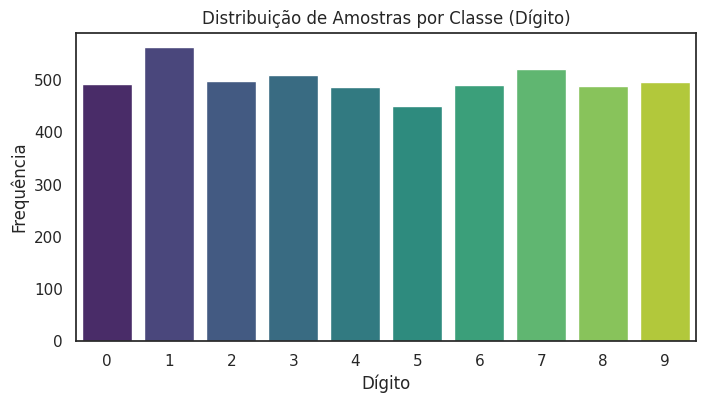

In [ ]:
# 1. Gráfico de distribuição de amostras por dígito
classes, counts = np.unique(y_sub, return_counts=True)

plt.figure(figsize=(8, 4))
sns.barplot(x=classes, y=counts, palette='viridis')
plt.title('Distribuição de Amostras por Classe (Dígito)')
plt.xlabel('Dígito')
plt.ylabel('Frequência')
plt.show()

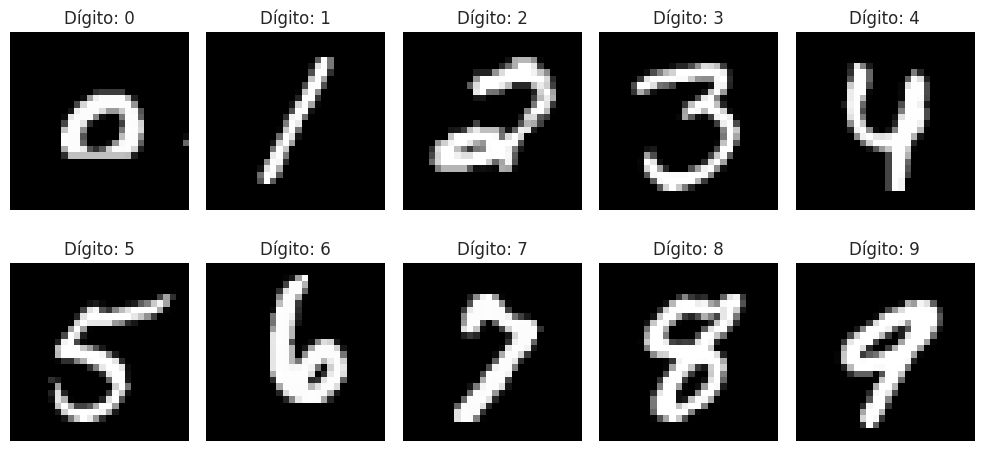

In [ ]:
# 2. Visualização de amostras reais do dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    # Encontra o índice da primeira ocorrência do dígito i
    idx = np.where(y_sub == str(i))[0][0]
    # Redimensiona o vetor unidimensional de 784 para 28x28 pixels
    img = X_sub[idx].reshape(28, 28)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Dígito: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

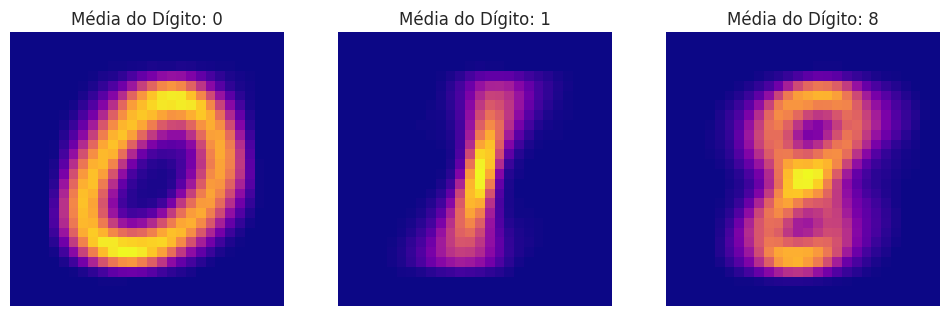

In [ ]:
# 3. Visualização da "Imagem Média" para os dígitos 0, 1 e 8
# A imagem média representa o centróide estatístico dos pixels para cada classe.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
digits_to_plot = ['0', '1', '8']

for i, digit in enumerate(digits_to_plot):
    # Filtra os dados daquele dígito
    digit_imgs = X_sub[y_sub == digit]
    # Calcula a média por pixel
    mean_img = digit_imgs.mean(axis=0).reshape(28, 28)

    axes[i].imshow(mean_img, cmap='plasma')
    axes[i].set_title(f"Média do Dígito: {digit}")
    axes[i].axis('off')

plt.show()

### 2.4 Principais Transformações

#### 1. Normalização de Escala
Os pixels estão originalmente no intervalo de $0$ a $255$. Dividiremos os valores por $255.0$ para normalizar os dados no intervalo de $[0, 1]$. Essa transformação linear simples impede que o gradiente exploda durante otimizações e garante estabilidade numérica para classificadores como SVM e Redes Neurais.

#### 2. Redução de Dimensionalidade (PCA)
Trabalhar no espaço de 784 dimensões pode acarretar na "maldição da dimensionalidade". Utilizaremos o **PCA (Principal Component Analysis)** para extrair componentes ortogonais que maximizam a variância explicada, permitindo treinar modelos muito mais rápidos e menos propensos a overfitting.

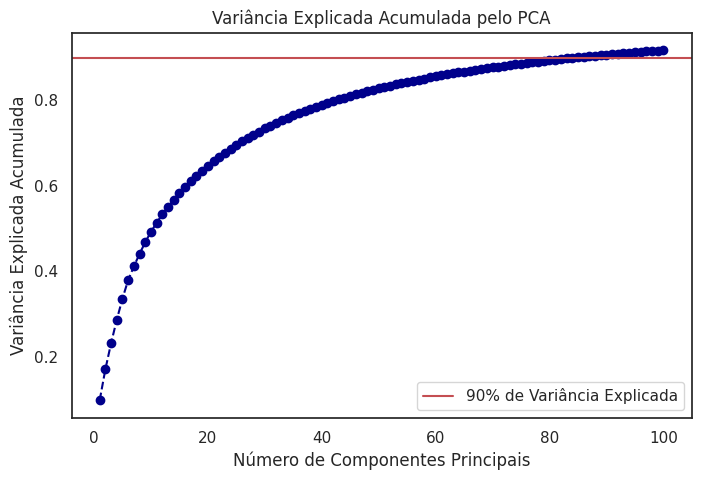

São necessários apenas 85 componentes de PCA para explicar 90% da variância do MNIST!


In [ ]:
# Normalização dos dados de pixels
X_normalized = X_sub / 255.0

# Aplicação do PCA para inspecionar variância explicada
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_normalized)

# Plotagem da variância explicada acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), cumulative_variance, marker='o', linestyle='--', color='darkblue')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% de Variância Explicada')
plt.title('Variância Explicada Acumulada pelo PCA')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.legend()
plt.show()

# Quantidade de componentes necessários para atingir 90% da variância
n_comps_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"São necessários apenas {n_comps_90} componentes de PCA para explicar 90% da variância do MNIST!")

---

## 3. Principais Decisões de Projeto

### 3.1 Descrição das Decisões
1.  **Normalização para o Intervalo $[0, 1]$:** Essencial para algoritmos de descida de gradiente (redes neurais) e funções de distância (como SVM com kernel RBF).
2.  **Redução de Dimensionalidade via PCA:** Decidimos utilizar os 50 primeiros componentes principais (que cobrem cerca de 90% da variância) para treinar classificadores SVM na próxima fase. Isso reduz as dimensões do dataset em mais de 93% ($784 \rightarrow 50$), otimizando drasticamente o consumo de memória RAM e processamento.
3.  **Preservação da Matriz Completa para Deep Learning:** Enquanto modelos tradicionais utilizarão o PCA, para a rede convolucional profunda (CNN) manteremos as features completas remodeladas em matrizes $28 \times 28$, uma vez que CNNs dependem da coerência espacial vizinha das imagens.

### 3.2 Revisão da Literatura
*   **LeCun et al. (1998)** mostram que a normalização das intensidades de cinza é um pré-requisito crítico.
*   Trabalhos clássicos utilizando SVM comprovam que a redução para o espaço de componentes de PCA preserva o desempenho discriminatório do classificador com um custo computacional muito inferior.

### 3.3 Avaliação do Impacto na Próxima Etapa
No TP3, avaliaremos o impacto do PCA comparando o tempo de execução e a acurácia de um classificador Support Vector Machine (SVM) treinado com:
*   Os 784 pixels brutos normalizados.
*   Os 50 componentes principais obtidos via PCA.

---

## 4. Metodologia de Modelagem e Simulação Computacional (TP3)

### 4.1 Algoritmos de Machine / Deep Learning Pretendidos
Para a fase de modelagem manual (TP3), selecionamos os seguintes algoritmos:
1.  **Support Vector Classifier (SVC):** Classificador clássico linear e não linear (kernel RBF), muito eficiente em espaços de dimensão média a alta.
2.  **Rede Neural Multicamadas (MLP):** Uma rede totalmente conectada clássica com camadas ocultas intermediárias para modelagem não linear.
3.  **Rede Neural Convolucional (CNN):** Implementação de uma arquitetura convolucional profunda básica usando TensorFlow/Keras ou PyTorch, explorando a estrutura espacial bidimensional nativa da imagem.

### 4.2 Métricas de Desempenho
*   **Acurácia Global:** Como as classes são bem balanceadas, a acurácia reflete fielmente a qualidade do classificador.
*   **F1-Score Macro:** Média harmônica do F1-score de cada um dos 10 dígitos, garantindo robustez caso alguma classe seja penalizada.
*   **Matriz de Confusão:** Crucial para identificar dígitios semanticamente parecidos que geram confusões mútuas (como 3 e 8, ou 4 e 9).

### 4.3 Referências de Comparação
Confrontaremos os modelos manuais contra:
1.  O baseline estatístico de **chute uniforme** (Acurácia teórica de 10%).
2.  O baseline do AutoML obtido via **FLAML no TP1** (Acurácia: ~92%), avaliando o quanto o ajuste manual de arquiteturas convolucionais consegue superar modelos tabulares tradicionais.
